# 07 · Bivariate analysis

Follow the app's six synthetic copula examples while keeping marginal behavior separate from dependence.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Margins and dependence
Each example links two saved Normal marginal analyses with one of AMH, Clayton, Frank, Gumbel, Joe or Normal copulas.
These are controlled teaching datasets, not observed river-gage case studies. Observed pairs are matched by index and exclude flagged low outliers.
Each named copula case has its own simulated paired sample, so the metric rows are descriptive and are not a cross-case model ranking.

,Setting,Saved choice
0,Analysis,BivariateAnalysis
1,MarginalX,Normal - Marginal X
2,MarginalY,Normal - Marginal Y
3,BayesianAnalysis.Type,DEMCzs
4,BayesianAnalysis.NumberOfChains,4
5,BayesianAnalysis.ThinningInterval,10
6,BayesianAnalysis.WarmupIterations,1750
7,BayesianAnalysis.Iterations,3500
8,BayesianAnalysis.UseSimulationDefaults,True
9,BayesianAnalysis.PRNGSeed,12345


,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,AMH Copula,see saved dependencies,BivariateAnalysis,-12.150560,-9.545390,-12.336077,0.014712,,Descriptive only — rows may use different resp...
1,Clayton Copula,see saved dependencies,BivariateAnalysis,-60.949327,-58.344157,-60.997490,0.022539,,Descriptive only — rows may use different resp...
2,Frank Copula,see saved dependencies,BivariateAnalysis,-110.219011,-107.613840,-110.190014,0.013175,,Descriptive only — rows may use different resp...
3,Gumbel Copula,see saved dependencies,BivariateAnalysis,-66.073832,-63.468662,-66.052310,0.014323,,Descriptive only — rows may use different resp...
4,Joe Copula,see saved dependencies,BivariateAnalysis,-92.857497,-90.252326,-92.864383,0.014226,,Descriptive only — rows may use different resp...
5,Normal Copula,see saved dependencies,BivariateAnalysis,-95.731764,-93.126594,-95.687412,0.014157,,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,AMH Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
1,Clayton Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
2,Frank Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
3,Gumbel Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
4,Joe Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt
5,Normal Copula,saved-app,sha256:56f9408158fe,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


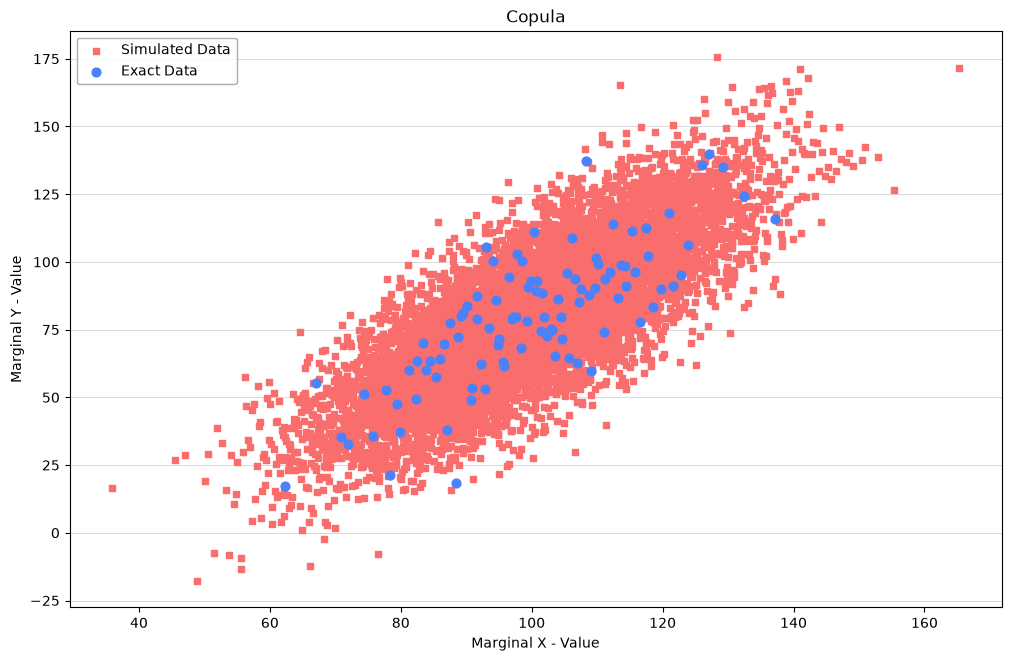

In [2]:
PROJECT = "bivariate-distribution-examples"
names = ["AMH Copula", "Clayton Copula", "Frank Copula", "Gumbel Copula", "Joe Copula", "Normal Copula"]
cases = [saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names]
display(cases[-1].settings)
display(case_metrics(cases))
display(case_provenance(cases))
cases[-1].show("scatter_values")

## Value and marginal-probability coordinates
In probability coordinates, observed values use their empirical plotting-position complements;
simulated values use their fitted marginal CDFs. The simulation retains the app's original seed and output-length cap.
Density contours use the app's log joint density grid; joint-exceedance contours instead show P(X>x, Y>y).

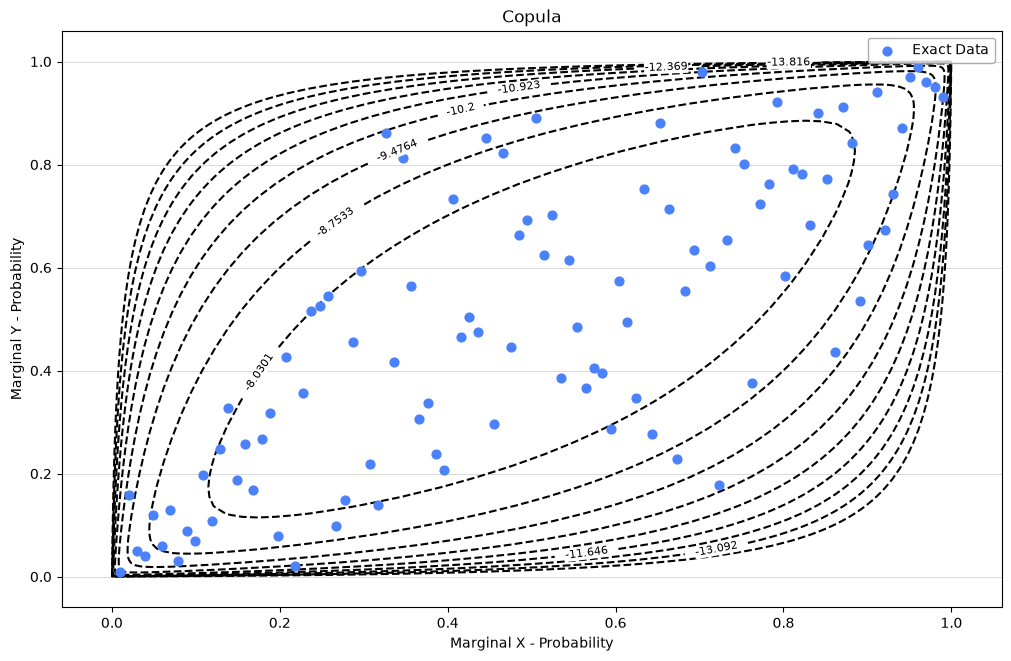

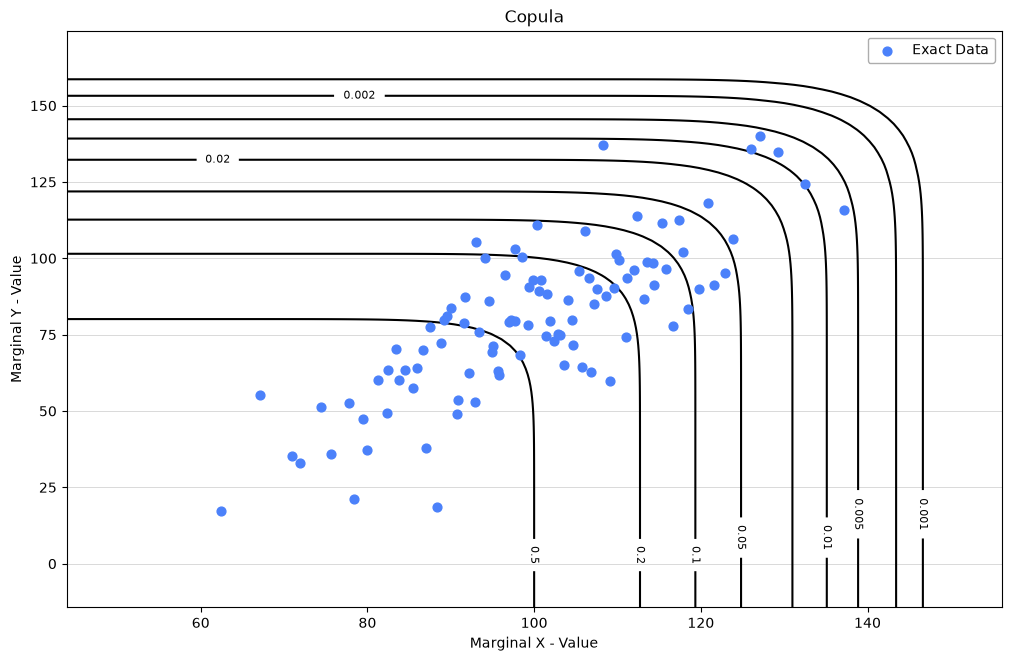

In [3]:
cases[-1].show("density_cdf")
cases[-1].show("joint_exceedance_values")

**Interpretation:** similar marginal fits can still imply different joint tails. Notebook 08 carries the joint model through a specified response function; a copula contour alone is not a response-frequency curve.